In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
values = [48, 50, 49, 51, 52, 47, 50, 49, 51, 50, 180, 200] 
df = pd.DataFrame({"value": values})

count     12.000000
mean      73.083333
std       54.794589
min       47.000000
25%       49.000000
50%       50.000000
75%       51.250000
max      200.000000
Name: value, dtype: float64


<Axes: title={'center': 'Value distribution'}>

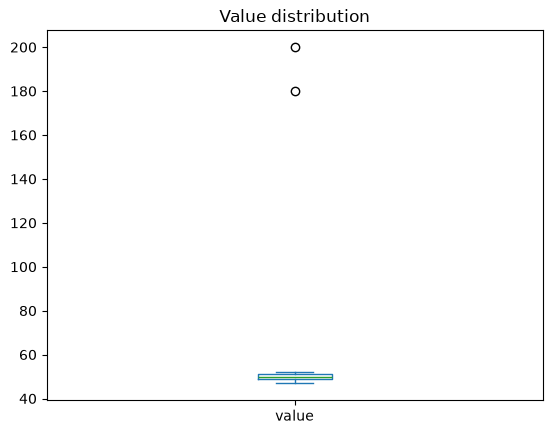

In [2]:
print(df["value"].describe()) 
df["value"].plot(kind="box", title="Value distribution") 

In [3]:
q1 = df["value"].quantile(0.25) 
q3 = df["value"].quantile(0.75) 
iqr = q3 - q1 
lower = q1 - 1.5 * iqr 
upper = q3 + 1.5 * iqr 
df["iqr_outlier"] = ~df["value"].between(lower, upper) 

In [4]:
mean = df["value"].mean() 
std = df["value"].std(ddof=1) 
df["z_score"] = (df["value"] - mean) / std 
df["z_outlier"] = df["z_score"].abs() > 3 

In [5]:
median = df["value"].median() 
mad = np.median(np.abs(df["value"] - median)) 
if mad == 0: 
   df["modified_z"] = np.nan 
else: 
   df["modified_z"] = 0.6745 * (df["value"] - median) / mad 
df["modified_z_outlier"] = df["modified_z"].abs() > 3.5 

In [6]:
flags = df[df[["iqr_outlier", "z_outlier", 
"modified_z_outlier"]].any(axis=1)] 
print(flags[["value", "iqr_outlier", 
"z_outlier", "modified_z_outlier"]]) 

    value  iqr_outlier  z_outlier  modified_z_outlier
10    180         True      False                True
11    200         True      False                True


In [7]:
df["value_raw"] = df["value"] 
df["value_capped"] = df["value"].clip(lower, upper) 
comparison = df[["value_raw", "value_capped", 
"iqr_outlier", "modified_z_outlier"]]